In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver


In [3]:
load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-3.6-flash')


In [4]:
# state
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [6]:
checkpointer = MemorySaver()
# graph
graph = StateGraph(ChatState)
# node
graph.add_node('chat_node', chat_node)
# edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)
# complie
chatbot = graph.compile(checkpointer=checkpointer)

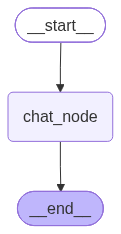

In [7]:
chatbot

In [18]:

initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}


config = {
    "configurable": {
        "thread_id": "1"
    }
}

result = chatbot.invoke(initial_state, config=config)

print(result["messages"][-1].content)

c:\Users\sd\OneDrive\Desktop\LangGraph-Agentic_AI-\myenv\Lib\site-packages\langchain_google_genai\chat_models.py:3157: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


[{'type': 'text', 'text': 'The capital of India is **New Delhi**.', 'extras': {'signature': 'EpYECpMEARFNMg/ArNADJw3JLZ6FJlmOIcN5Uzsyny2aWEHguiNnV67xHatKchUFRHjV8BZpCmSkh0mWUsi75sNW1DElRR5n64zq1oELUPJPVahPbYHq/YNgQfwQDac4HoRAzYk8MzFSJir+QNXH9MkGmSX2JTSTUMJENrzL3Kqem0Uuh4xVZu5zV1x/cusL0CSiPOTHj0Ey7MS7R2dsrXUUELm3swusPIVDWXsD5KF1N7kKY6hKNh1Oi0zZ5/VJSTIFZALXaJgKKT/PLJ8xvhHz5o8veqQw5McPH13vdRJNjVcrUARA+C6OPlXr2snBwSRIENzYmkgiZR7+FtiUS4oaFvlgX2Lz7cf05O9GPF9SaarjnNIIFizRk2J3yyeU6INHLc/0wjc/TljK/aCbYMnfxzGKvLSntCriU+3flkJFOTwwQjtNzfBA2lnaVQuMzhUwLsydh8jI8xvrI6OoUmYmHMcwViThcDrEQvgHkTPj+lJAnr+EmDPK3KBbFp+JaYutLF0mB9J04jmNk4DW+Zx/KOQ6Ftj8blN72RmA0m9d67U2UlL0bo7tHX9l+kGE1S/zDgQ4BAGWUEXOxM5bFRivpLdU4rmr0T8hM+cN8ywswLIm24MmrqbzoP6EgNw1RmR+NMhb9CWC4BM4u5y8F8GlYEBT9e+TEstnbzNIMXiMfbPXZV4ur8NMRBJH4yGMje0orQIEae4I'}}]


### Devloping chatting feature(above is basic sclaton) in which we are doing this things in loop till user not say 'exit','quit','bye'

In [17]:
thread_id = '1'

while True:
    user_message = input("Type here: ").strip()
    if not user_message:
      continue
    print('User:',user_message)

    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]},config=config )

    print("AI:", response["messages"][-1].content[0]["text"])

User: hi


c:\Users\sd\OneDrive\Desktop\LangGraph-Agentic_AI-\myenv\Lib\site-packages\langchain_google_genai\chat_models.py:3157: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


AI: Hi Amar! 👋 Ready whenever you are!
User: how are u


c:\Users\sd\OneDrive\Desktop\LangGraph-Agentic_AI-\myenv\Lib\site-packages\langchain_google_genai\chat_models.py:3157: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


AI: Still doing great, Amar! 😊 How about you?


KeyboardInterrupt: Interrupted by user

In [12]:
# for see history a/c to their id
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='b32ade8b-1829-49d2-a5d1-de9af856f733'), AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EoMFCoAFARFNMg/thd24lhfByw2fy7JhttOxuRGdSM6A31el+zfikGIBqgA3Pxm2dycRUC1r6R/kvdjOpg8JtpzuJ7zbVYqhluVl2JJPpvlcidMip32cof5RDCRDSuFyo/EpaPjLEqsQT5exLwT8MBgVoZrlIm6PUs9OGM7nWw8MFijwBMpFwMDbKMDNiUdczJ7XhPORRbC0gxY8x2PYS1zFzTIQl8ks0siFXU2Vl5CefCfI5lPS9Z2mdF5KlEhc2Ft4RFgD+55XN2DTmCB75J7lXgTcxDL3gLXdS0AKZqD0cT2cWdphLIj6OBZFJqpO7ya0kSUgKSrs9GwrbDC/34aSm87YAzKhz+d99cGCG6ocN9XD0JqfjO3vGlf/RkHODda+p88IeEmxtlmT1YqvF3GmrAuigmf2CwOy6h4QBDz012X1P4XpWBVm6Kh9cUUDGi+g8PYEIZKLMXKNL+sUVovF+8ORtPfhra0s74C9U777w3EooLcu2lGhfiAzQyTfajVdEolJbD+EhJHx5vnPuNqN75maCsR57GcKtSDe9QgmdXO1Ik/TqTo1fZzy71Yj43mh/9d8SxlVoNqgdVVLIQ/f4AS0jk5EiJyn4jEucvtksnQYluyS3nWDzjErPLs532H8X1Ky9tee7R85PE3CimhDVo8AxzGLCB06AMG2ocDwgoA3L6oilRgUE315ZozHJKdb3+TQAHcQi/bfJUmpKoPDvUUBm+k2vqKct8hqr